Ładowanie Danych
Plik wczytany.Dostępne kolumny:
['link', 'Data-Name', 'data type', 'default task', 'attribute-type', 'instances', 'attributes', 'year']

 Head
                                                link  \
0    https://archive.ics.uci.edu/ml/datasets/Abalone   
1      https://archive.ics.uci.edu/ml/datasets/Adult   
2  https://archive.ics.uci.edu/ml/datasets/Annealing   
3  https://archive.ics.uci.edu/ml/datasets/Anonym...   
4  https://archive.ics.uci.edu/ml/datasets/Arrhyt...   

                      Data-Name            data type    default task  \
0                       Abalone         Multivariate  Classification   
1                         Adult         Multivariate  Classification   
2                     Annealing         Multivariate  Classification   
3  Anonymous Microsoft Web Data  Recommender-Systems     Categorical   
4                    Arrhythmia         Multivariate  Classification   

               attribute-type  instances  attributes    year  
0  Cate

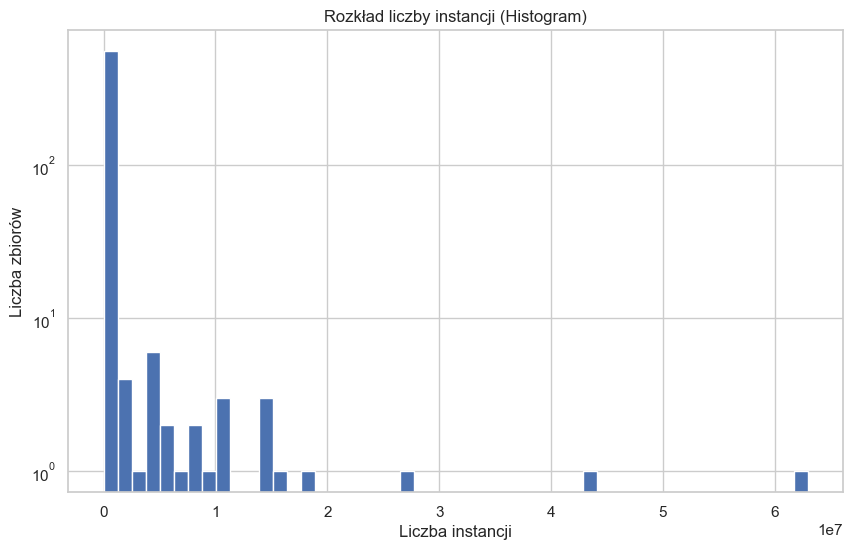

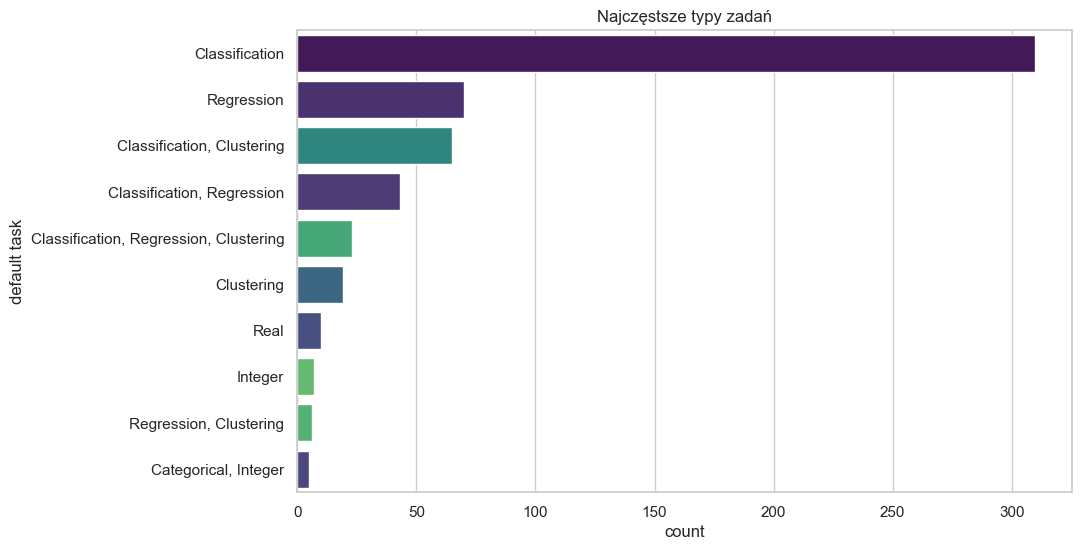


 Korelacje


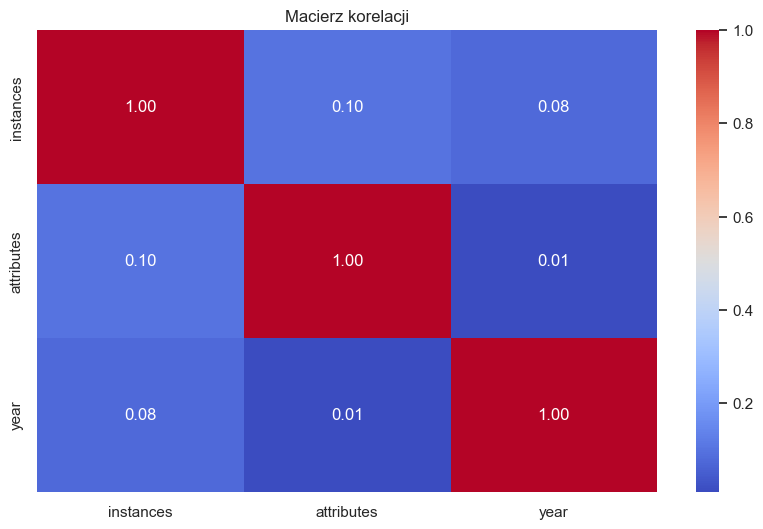

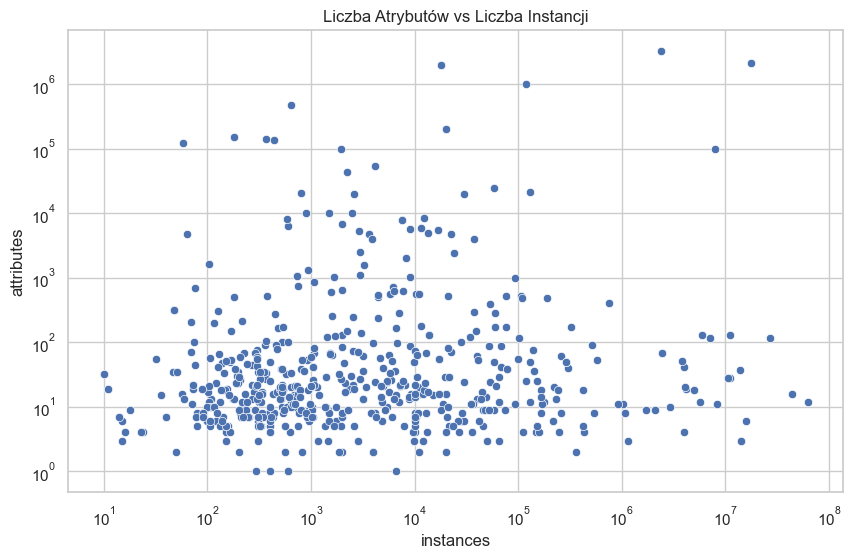

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.DataFrame()


print("Ładowanie Danych")
try:
    df = pd.read_csv('UCI-datset.csv')

    df.columns = df.columns.str.strip()

    print("Plik wczytany.Dostępne kolumny:")
    print(list(df.columns))

except FileNotFoundError:
    print("Błąd: Nie znaleziono pliku.")


if not df.empty:


    print("\n Head")
    print(df.head())

    print("\n Info")
    print(df.info())

    print("\n Describe")
    print(df.describe())


    print("\n Braki danych")
    missing = df.isna().sum()
    print(missing[missing > 0])


    print("\n Wykresy")

    #Histogram
    if 'instances' in df.columns:
        df['instances'].hist(bins=50)
        plt.title('Rozkład liczby instancji (Histogram)')
        plt.xlabel('Liczba instancji')
        plt.ylabel('Liczba zbiorów')
        plt.yscale('log')
        plt.show()

    #Typy zadań
    if 'default task' in df.columns:
        top_tasks = df['default task'].value_counts().nlargest(10).index

        sns.countplot(
            data=df,
            y='default task',
            order=top_tasks,
            hue='default task',
            palette='viridis',
            legend=False
        )
        plt.title('Najczęstsze typy zadań')
        plt.show()


    print("\n Korelacje")

    numeric_df = df.select_dtypes(include=['float64', 'int64'])

    if not numeric_df.empty:
        sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Macierz korelacji')
        plt.show()

        if 'instances' in df.columns and 'attributes' in df.columns:
            sns.scatterplot(data=df, x='instances', y='attributes')
            plt.xscale('log')
            plt.yscale('log')
            plt.title('Liczba Atrybutów vs Liczba Instancji')
            plt.show()

# Raport EDA:

Celem analizy było zrozumienie struktury danych, jakości zbioru oraz relacji między zmiennymi.

# 1. Wstępna inspekcja danych
Po wczytaniu danych metodami `head()`, `info()` oraz `describe()`, ustaliłem następujące fakty:
Rozmiar zbioru: Tabela zawiera 620 rekordów (wierszy) i 8 kolumn.
Zakres czasowy: Zbiory danych pochodzą z lat 1987–2021.
Skala danych: Mamy do czynienia z ogromnym zróżnicowaniem. Najmniejsze zbiory mają zaledwie 10 instancji, podczas gdy największy posiada ich aż 63 miliony (6.300000e+07).

# 2. Jakość danych i braki (Missing Values)
Zidentyfikowano braki w kluczowych kolumnach:
attribute-type: 137 braków (największy problem – brak informacji o typie danych).
attributes: 63 braki.
instances: 34 braki.
default task: 29 braków.

Nie można automatycznie trenować modelu na surowych danych co nauczyłem się z zajęć. Konieczna byłaby imputacja (uzupełnienie) braków lub usunięcie niekompletnych wierszy, aby uniknąć błędów wykonania.

# 3. Analiza Rozkładów (Wizualizacja)

Na podstawie wykresów zauważyłem:

Histogram Instancji (Skala Logarytmiczna):**
    Rozkład jest silnie prawoskośny. Zdecydowana większość zbiorów jest relatywnie mała (poniżej 10 tys. wierszy). Ze względu na występowanie kilku gigantycznych zbiorów (powyżej 1 mln instancji), konieczne było użycie skali logarytmicznej na wykresie, aby dane były czytelne.

Typy zadań :
    Repozytorium jest zdominowane przez zbiory do zadań Classification – jest ich ponad 300. Regresja i Klastrowanie są znacznie mniej popularne.


# 4. Korelacje i Zależności
Macierz korelacji oraz wykres punktowy Scatterplot doprowadziły do kluczowego wniosku:

Brak korelacji wymiarów: Współczynnik korelacji między liczbą instancji a liczbą atrybutów wynosi zaledwie 0.10.
Interpretacja: Oznacza to, że "duży" zbiór danych (wiele wierszy) wcale nie musi być skomplikowany (wiele kolumn). Istnieją zbiory typu Big Data z małą liczbą cech, jak i małe zbiory o bardzo wysokiej wymiarowości. Są to niezależne charakterystyki.

# Podsumowanie
Zbiór danych UCI posiada dużą rozpiętość historyczną i rozmiarową. Głównym wyzwaniem z tym plikiem jest obsługa brakujących wartości oraz standaryzacja kolumny z typami zadań.